# Flight Fare Prediction Using Machine Learning


## Introduction

Air travel has become one of the most popular modes of transportation due to its speed and convenience. 
However, flight ticket prices are highly dynamic and vary based on several factors such as airline, route, journey date, duration, demand, and number of stops. 
These fluctuations make it difficult for passengers to determine the best time to book tickets.

Machine Learning provides an effective solution for analyzing historical flight data and identifying patterns that influence ticket prices. 
By leveraging predictive models, it is possible to estimate future flight fares with a reasonable level of accuracy. 
This project focuses on analyzing flight fare data, performing exploratory data analysis, and developing machine learning models to predict flight ticket prices.

## Problem Statement

Flight ticket prices are highly dynamic and difficult to predict due to several influencing factors such as airline, source, destination, duration, number of stops, departure time, and arrival time. The objective of this project is to analyze historical flight fare data and develop a machine learning model that can accurately predict flight ticket prices. This prediction system can help customers plan their journeys more effectively and assist airlines in making informed pricing decisions

## Dataset Information

The dataset contains information about various flights operating between different cities. It includes details such as airline name, journey date, source, destination, route, departure time, arrival time, duration, total stops, additional information, and ticket price.

Dataset Features:

- Airline
- Date_of_Journey
- Source
- Destination
- Route
- Arrival_Time
- Duration
- Total_Stops
- Additional_Info
- Price (Target Variable)

## Dataset Size:
- Number of Records: 10,683
- Number of Features: 11

## Dataset Link:
              https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/flight-fare.zip

## Machine Learning Pipeline

The following machine learning pipeline was followed in this project:


### Data Collection and Loading
- Load the flight fare dataset and understand its structure.

### Data Understanding
- Analyze features, data types, and target variable

### Data Cleaning
- Handle missing values and remove inconsistencies.

### Exploratory Data Analysis (EDA)
- Visualize data and identify patterns, trends, and relationships.

### Feature Engineering
- Extract useful information from date, time, and duration features.

### Data Preprocessing
- Encode categorical variables and prepare data for machine learning algorithms

### Model Building
- Train multiple machine learning models on the prepared dataset.

### Model Evaluation
- Evaluate models using suitable performance metrics.

### Model Comparison
- Compare model performance and identify the best-performing model.

### Prediction and Conclusion
- Use the selected model for flight prediction and summarize findings.

## Importing Required Libraries

In [2]:
# Basic data handling
import pandas as pd
import numpy as np

# Visualization (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# To display warnings cleanly
import warnings
warnings.filterwarnings("ignore")

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Regression Models 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Model evaluation 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
#load the dataset
df = pd.read_csv("flight_fare.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'flight_fare.csv'

In [ ]:
#checking first five rows
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
#checking last five rows
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL ? GOI ? BOM ? COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [ ]:
#checking the info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
#checking the describe functions
df.describe()


,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [ ]:
#check missing values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Only two columns had 1 missing value each.

In [ ]:
df.dropna(inplace=True)

In [ ]:
#recheck
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

so I removed them using dropna().

In [ ]:
#check data types
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [ ]:
df.shape

(10682, 11)

In [ ]:
df.nunique()

Airline              12
Date_of_Journey      44
Source                5
Destination           6
Route               128
Dep_Time            222
Arrival_Time       1343
Duration            368
Total_Stops           5
Additional_Info      10
Price              1870
dtype: int64

In [ ]:
#check the duplicated values
df.duplicated().sum()

np.int64(220)

In [ ]:
#remove the duplicated values
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

EDA was performed to explore the dataset and gain useful insights.

## Univariate Analysis

### Distribution of Flight Prices

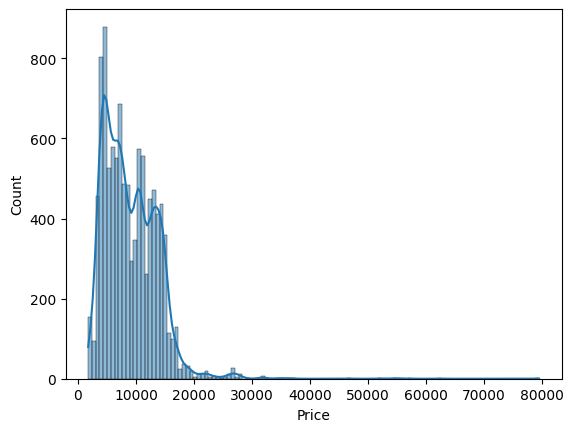

In [ ]:
sns.histplot(df['Price'], kde=True)
plt.show()

- Flight prices are not evenly distributed.
- Most flights fall in a mid-price range.
- Few flights have very high prices (outliers).

# Number of Flights by Airline

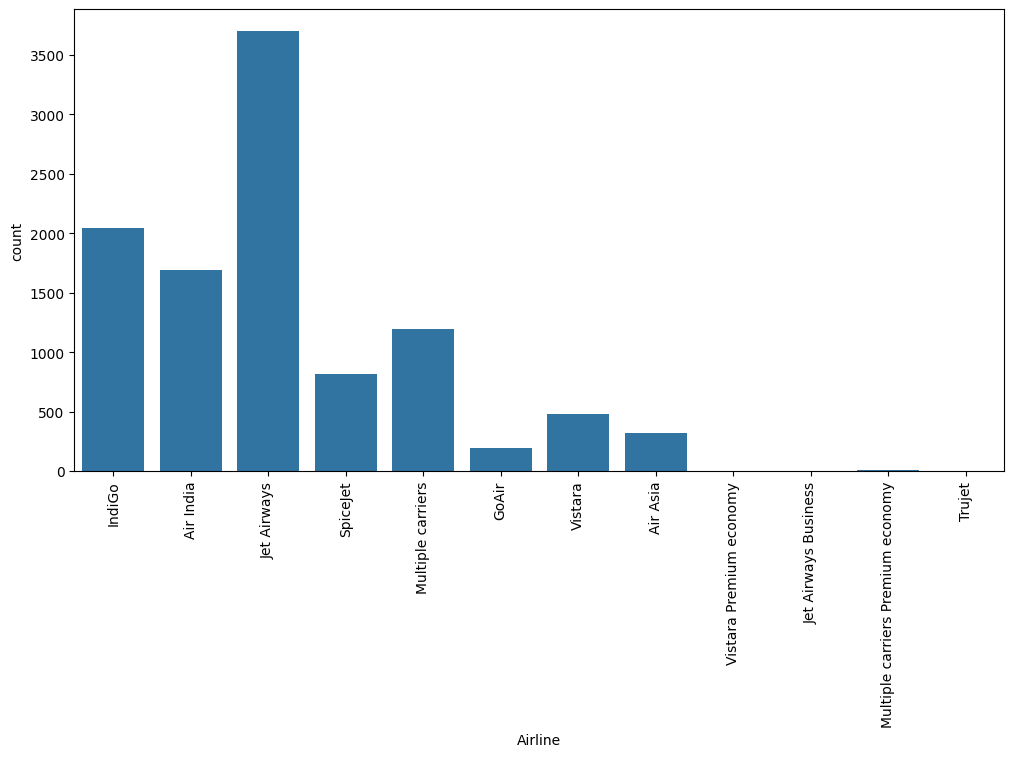

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Airline')
plt.xticks(rotation=90)
plt.show()

- This graph compares how many flights each airline operates
- It helps identify which airlines are most active in the dataset
- Some airlines may show very low or zero flights

## Bivariate Analysis

### Airline-wise Flight Price Analysis

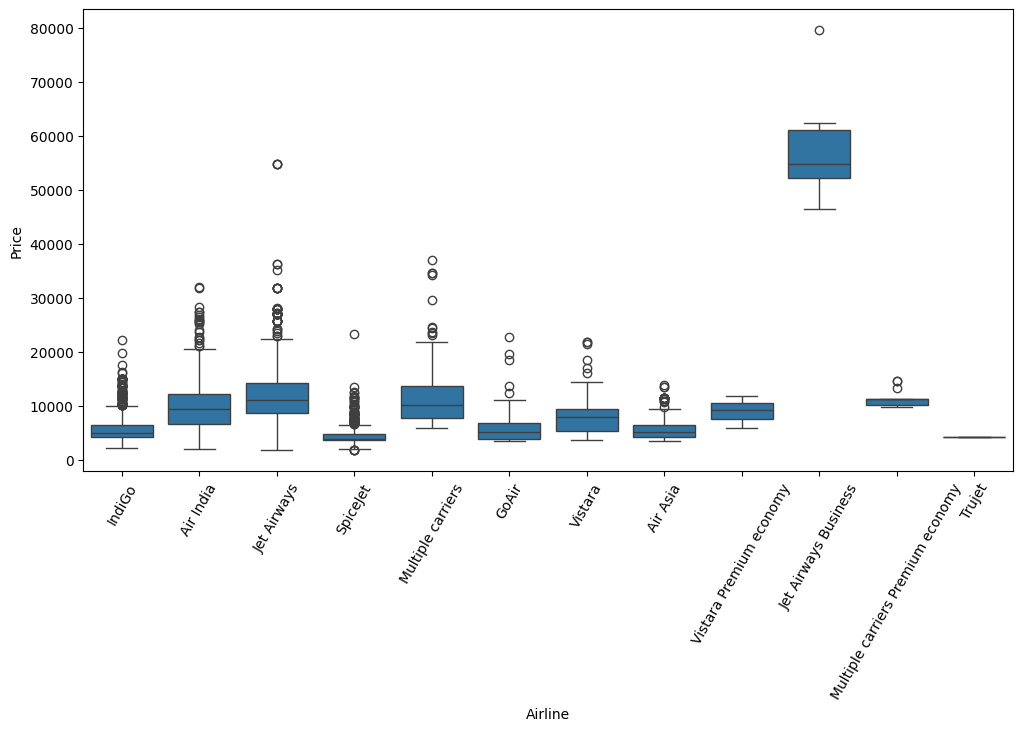

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=60)
plt.show()

- Some airlines consistently show higher average ticket prices.
- Budget airlines generally offer lower and more affordable fares.
- Premium airlines tend to have higher price ranges due to better services.


# Price vs Number of Stops

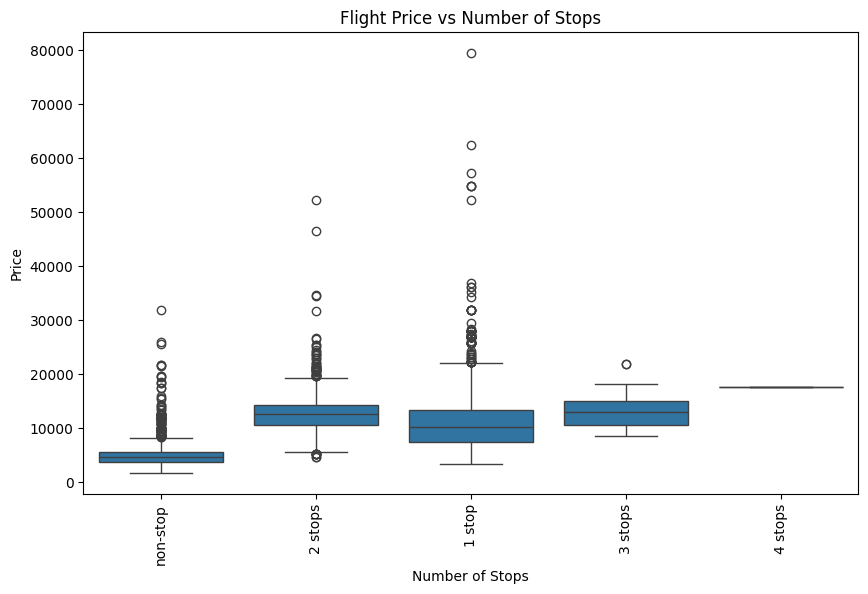

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Total_Stops', y='Price', data=df)

plt.title('Flight Price vs Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Price')

plt.xticks(rotation=90)
plt.show()

- Price varies based on number of stops
- 1-stop flights show highest variation
- Stops are an important feature for prediction 

### Feature Correlation Heatmap

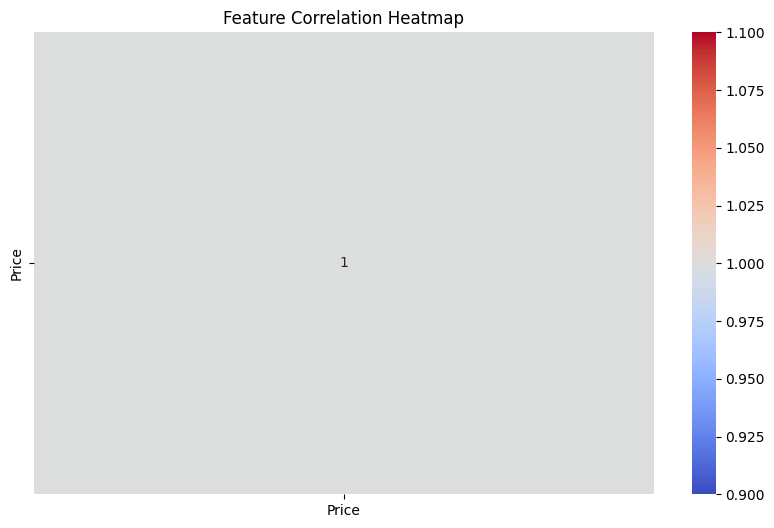

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

- Price has mild correlation with few features
- Most features are weakly related
- Helps in selecting important variables for ML

### EDA Conclusion

- Flight prices vary based on factors like airline, number of stops, and duration. 
- Most flights are in a moderate price range, with few high-priced outliers. 
- Some features show clear impact on price, while others have weak relationships. 
- Overall, the dataset is suitable for building a machine learning model to predict flight prices.

### Outlier Analysis

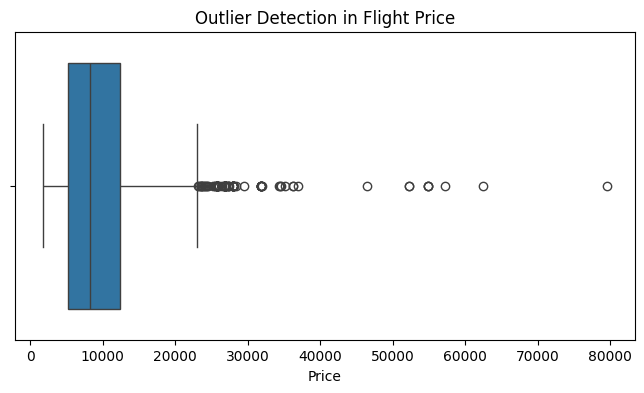

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Price'])
plt.title("Outlier Detection in Flight Price")
plt.show()


- The Price column contains some extreme values. Since flight fares naturally vary based on airline, route, travel season, and demand, these observations were considered valid and retained for model training.

# Data Preprocessing

Converted date and categorical features into numeric form and
Removed unnecessary column

In [ ]:
#check the columns
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [ ]:
#drop the unnecessary columns
df.drop(['Route', 'Additional_Info'], axis=1, inplace=True)

In [ ]:
df

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,3897
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2 stops,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,13302
...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,19:55,22:25,2h 30m,non-stop,4107
10679,Air India,27/04/2019,Kolkata,Banglore,20:45,23:20,2h 35m,non-stop,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,08:20,11:20,3h,non-stop,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,11:30,14:10,2h 40m,non-stop,12648


In [ ]:
df['Total_Stops'] = df['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})

In [ ]:
df

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302
...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,19:55,22:25,2h 30m,0,4107
10679,Air India,27/04/2019,Kolkata,Banglore,20:45,23:20,2h 35m,0,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,08:20,11:20,3h,0,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,11:30,14:10,2h 40m,0,12648


This step is done to convert categorical text into numeric form so ML model can use it for prediction.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df

,Total_Stops,Price,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,...,Duration_9h 15m,Duration_9h 20m,Duration_9h 25m,Duration_9h 30m,Duration_9h 35m,Duration_9h 40m,Duration_9h 45m,Duration_9h 50m,Duration_9h 55m,Duration_9h 5m
0,0,3897,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,7662,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,13882,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,6218,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,13302,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,4107,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10679,0,4145,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10680,0,7229,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10681,0,12648,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Categorical features were converted into numeric form using one-hot encoding to make them suitable for machine learning.

# Feature Selection (X and y Split)

In [ ]:
X = df.drop('Price', axis=1)  #input features
y = df['Price']   #target variable

In [ ]:
X

,Total_Stops,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Duration_9h 15m,Duration_9h 20m,Duration_9h 25m,Duration_9h 30m,Duration_9h 35m,Duration_9h 40m,Duration_9h 45m,Duration_9h 50m,Duration_9h 55m,Duration_9h 5m
0,0,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10679,0,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10680,0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10681,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
y

0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10678     4107
10679     4145
10680     7229
10681    12648
10682    11753
Name: Price, Length: 10462, dtype: int64

- Dataset was split into input features (X) and target variable (Price) to prepare for model training.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.shape

(8369, 1994)

In [ ]:
X_test.shape

(2093, 1994)

y_test.shape

In [ ]:
y_train.shape

(8369,)

The dataset was successfully split into training (80%) and testing (20%) sets for model development and evaluation.

# Model Building and Training

# Linear Regression:

- Linear Regression was used as a baseline model for flight price prediction



In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


- A Linear Regression model was trained using the training dataset to learn the relationship between input features and flight ticket prices.

In [ ]:
#Prediction Using Linear Regression
y_pred_lr = lr.predict(X_test)

In [ ]:
print(lr.predict(X_test))

[16100.65120656  3841.          4309.63628274 ... 11780.18236408
  8934.14954091 11889.83630325]


- The trained Linear Regression model was used to predict flight ticket prices for the test dataset.

Evaluate Linear Regression:

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

MAE: 1878.554374364274
RMSE: 3498.888868004762
R2 Score: 0.41285078966056377


The Linear Regression model achieved an R² Score of approximately 0.41, indicating that it explains about 41% of the variance in flight ticket prices. This suggests that more advanced models may provide better predictive performance.

# Decision Tree Regressor

- Decision tree Regressor was used to capture non-linear relationships in the flight price data

In [ ]:
# training

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

- A Decision Tree Regressor was trained on the training dataset to learn decision rules and capture complex relationships between flight features and ticket prices.

In [ ]:
#prediction using Decision tree regressor
y_pred_dt = dt.predict(X_test)

In [ ]:
print(dt.predict(X_test))

[14815.  3841.  4148. ... 12488.  6795. 13377.]


- The trained Decision Tree model was used to predict flight ticket prices for the test dataset based on the learned patterns from the training data.

In [ ]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE: 1253.7207357859531
RMSE: 2270.1885437428577
R2 Score: 0.752820733369174


- The Decision Tree Regressor significantly outperformed the Linear Regression model, achieving a higher R² Score and lower error values. This indicates that the model was better able to capture the complex relationships present in the flight price data

# Random forest regressor:

- Random Forest Regressor improved prediction accuracy by combining multiple decision trees

In [ ]:
#Random forest regressor training
rf = RandomForestRegressor(
    
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

- The Random Forest model was trained to learn patterns in flight data and predict ticket prices accurately."

In [ ]:
# Predict on test data
y_pred_rf = rf.predict(X_test)

In [ ]:
print(rf.predict(X_test))


[16573.61        3841.94666667  4231.01       ... 12051.92
  6913.26       13432.3       ]


The model predicted flight ticket prices for the test dataset

In [ ]:
#Model Evaluation
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1131.9676187309929
RMSE: 1978.4432868555418
R2 Score: 0.8122692587686214


- The Random Forest model achieved an R² score of 0.81, indicating good predictive performance on the flight price dataset

# XG Boost Regressor:

- XGBoost was implemented to improve flight price prediction accuracy by learning complex patterns in the data

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

- The XGBoost model was trained to learn complex patterns in flight price data

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
xgb.predict(X_test)

array([17566.436 ,  4001.6365,  4288.647 , ..., 12057.443 ,  9970.193 ,
       10477.511 ], shape=(2093,), dtype=float32)

- The XGBoost model successfully generated flight price predictions for the test dataset

In [ ]:

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)


print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1455.434326171875
RMSE: 2227.3621169446155
R2 Score: 0.762058675289154


- Among all the models tested, Random Forest Regressor delivered the best performance with an R² score of 0.8123 and was selected as the final model for flight price prediction

### Model Comparison

The performance of four machine learning models was evaluated using MAE, RMSE, and R² Score

In [ ]:


comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'XGBoost Regressor'
    ],
    'MAE': [
        1253.7207,
        1878.5544,
        1131.9676,
        1455.4343
    ],
    'RMSE': [
        2270.1885,
        3498.8889,
        1978.4433,
        2227.3621
    ],
    'R2 Score': [
        0.7528,
        0.4129,
        0.8123,
        0.7621
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1253.7207,2270.1885,0.7528
1,Decision Tree Regressor,1878.5544,3498.8889,0.4129
2,Random Forest Regressor,1131.9676,1978.4433,0.8123
3,XGBoost Regressor,1455.4343,2227.3621,0.7621


Among all models, Random Forest Regressor achieved the highest R² Score and the lowest prediction error. Therefore, Random Forest Regressor was selected as the final model for production deployment and flight price prediction

## Challenges Faced

### Data Preprocessing Complexity

The dataset contained multiple types of features such as categorical variables (Airline, Source, Destination), date-time values, and duration formats. Converting these into a machine-learning-friendly format required careful preprocessing and feature extraction. Special attention was needed to handle Date_of_Journey, Arrival_Time, and Duration columns.

### Complex Feature Engineering Requirements

A major challenge was extracting useful information from raw features. The Duration column, in particular, was provided in a non-uniform string format (e.g., “2h 50m”), requiring decomposition into hours and minutes. Additionally, temporal features such as departure and arrival times were transformed into cyclical and discrete variables to improve model interpretability and performance.

### High Cardinality in Categorical Variables

Features like Airline, Route, and Destination had multiple unique categories. After encoding, this increased the dimensionality of the dataset, making the model more complex and computationally expensive.

### Data Cleaning and Formatting Issues

The dataset contained inconsistent formats in time-related features, which required multiple transformations to convert them into a usable structure for analysis and model training.

### Model Selection and Performance Variation

Different machine learning models showed varying performance levels. Comparing models such as Linear Regression and Random Forest was necessary to identify the best-performing model for prediction.

### Balancing Accuracy and Efficiency

A key challenge was achieving a balance between model accuracy and execution time, as more complex models provided better performance but required higher computational resources.

### Evaluation Metric Interpretation

Understanding evaluation metrics such as MAE, RMSE, and R² score required careful analysis to correctly interpret model performance.

## Conlusion – Flight Price Prediction

In this project, I built a Flight Price Prediction system using machine learning. The main goal was to predict flight ticket prices based on features like airline, source, destination, duration, and time details.

I performed data cleaning and feature engineering to make the data suitable for training. Then I trained different models and compared their performance. Among them, Random Forest Regressor gave better results compared to Linear Regression.

Finally, the model can predict flight prices with reasonable accuracy, which can help users plan their travel better.

In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

NameError: name 'model' is not defined